# Path-space Schrödinger bridges

This notebook generates `fig:sinkhorn-path-space-bridges`.  The figure illustrates the path-space view of the Schrödinger problem: first draw an endpoint coupling
$$
    \pi_\varepsilon \in \Pi(\alpha,\beta),
$$
then, conditionally on an endpoint pair $(x_i,y_j)$, fill the path by a Brownian bridge.  The limiting case $\varepsilon=0$ suppresses the bridge noise and recovers deterministic OT rays.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        ROOT = candidate.parent if candidate.name == "notebooks-figures" else candidate
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
import ot
from matplotlib.collections import LineCollection
from matplotlib.colors import to_rgba
from PIL import Image

from figure_style import BLUE, RED, DIRAC_MARKER_SIZE, figure_dir, interp_color, remove_axes, save_pdf, setup_matplotlib

setup_matplotlib()
rng = np.random.default_rng(20260611)

## Endpoint measures and couplings

We use two empirical measures with six equally weighted atoms: a compact red source cloud near the center and a blue target cloud arranged around it.  For $\varepsilon=0$ the endpoint coupling is the exact quadratic OT plan.  For $\varepsilon>0$ it solves
$$
    \min_{\pi\in\Pi(\alpha,\beta)}
        \int \|x-y\|^2\,d\pi(x,y)
        + \varepsilon\,\mathrm{KL}(\pi\mid\alpha\otimes\beta),
$$
which is computed by POT's log-domain Sinkhorn solver.  The largest value of $\varepsilon$ is kept moderate so the Brownian fluctuations remain visible without hiding the endpoint coupling.

In [2]:
NAME = "sinkhorn-path-space-bridges"
out = figure_dir(NAME)
thumb_dir = ROOT / "notebooks-figures" / "thumbnails"
thumb_dir.mkdir(parents=True, exist_ok=True)

# Six red source atoms form a compact central cloud. Six blue target atoms sit
# around them on a mildly irregular ring; the asymmetry avoids radial aliasing
# and makes the entropic spreading of endpoint couplings visible.
cloud_rng = np.random.default_rng(8)
angles = np.array([-2.72, -1.72, -0.58, 0.34, 1.42, 2.36])
radii = np.array([0.82, 1.02, 0.90, 1.08, 0.86, 0.98])
y = np.c_[radii * np.cos(angles), 0.82 * radii * np.sin(angles)]
y += cloud_rng.normal(scale=[0.030, 0.025], size=y.shape)

x = cloud_rng.multivariate_normal(
    mean=[0.00, 0.00],
    cov=[[0.022, 0.006], [0.006, 0.014]],
    size=6,
)
# Sort reproducibly for stable matching displays, but keep a two-dimensional
# cloud layout rather than a nearly one-dimensional ordering.
x = x[np.argsort(x @ np.array([0.64, 0.77]))]
y = y[np.argsort(np.arctan2(y[:, 1], y[:, 0]))]

a = np.ones(len(x)) / len(x)
b = np.ones(len(y)) / len(y)
C = ot.dist(x, y, metric="sqeuclidean")

epsilons = [
    (0.00, "eps-0.pdf", r"$\epsilon=0$"),
    (0.035, "eps-0p035.pdf", r"$\epsilon=0.035$"),
    (0.10, "eps-0p10.pdf", r"$\epsilon=0.10$"),
    (0.28, "eps-0p28.pdf", r"$\epsilon=0.28$"),
]

def endpoint_coupling(epsilon):
    if epsilon == 0:
        return ot.emd(a, b, C)
    P, log = ot.sinkhorn(
        a,
        b,
        C,
        reg=epsilon,
        method="sinkhorn_log",
        log=True,
        numItermax=50000,
        stopThr=1e-13,
    )
    P = np.maximum(P, 0)
    P = P / P.sum()
    return P

plans = {eps: endpoint_coupling(eps) for eps, _, _ in epsilons}
for eps, P in plans.items():
    err = 0.5 * (np.abs(P.sum(axis=1) - a).sum() + np.abs(P.sum(axis=0) - b).sum())
    cost = np.sum(P * C)
    entropy = -(P[P > 0] * np.log(P[P > 0])).sum()
    print(f"epsilon={eps:0.3f}, cost={cost:.3f}, displayed mass entropy={entropy:.3f}, marginal error={err:.2e}")


epsilon=0.000, cost=0.552, displayed mass entropy=1.792, marginal error=0.00e+00
epsilon=0.035, cost=0.564, displayed mass entropy=2.315, marginal error=7.55e-14
epsilon=0.100, cost=0.606, displayed mass entropy=3.002, marginal error=1.66e-14
epsilon=0.280, cost=0.673, displayed mass entropy=3.414, marginal error=2.44e-15


## Brownian bridge sampling

Conditionally on endpoints $(x_i,y_j)$, a Brownian bridge at noise level $\varepsilon$ is sampled as
$$
    Z_t = (1-t)x_i+t y_j + \sqrt{\varepsilon/2}\,\bigl(B_t-tB_1\bigr).
$$
The factor $1/2$ is the convention matching an endpoint heat kernel of the form $\exp(-\|x-y\|^2/\varepsilon)$, up to normalizing constants.  We sample a total budget of 60 paths from the discrete coupling with a multinomial draw.

In [3]:
def brownian_bridge_noise(epsilon, n_steps, rng):
    if epsilon == 0:
        return np.zeros((n_steps, 2))
    dt = 1.0 / (n_steps - 1)
    increments = rng.normal(scale=np.sqrt(dt), size=(n_steps - 1, 2))
    brownian = np.vstack([np.zeros((1, 2)), np.cumsum(increments, axis=0)])
    t = np.linspace(0, 1, n_steps)[:, None]
    bridge = brownian - t * brownian[-1]
    return np.sqrt(epsilon / 2.0) * bridge


def sample_paths(P, epsilon, *, total_paths=60, n_steps=72, seed=0):
    rr = np.random.default_rng(seed)
    counts = rr.multinomial(total_paths, P.ravel()).reshape(P.shape)
    ts = np.linspace(0, 1, n_steps)
    paths = []
    pairs = []
    for i in range(P.shape[0]):
        for j in range(P.shape[1]):
            for _ in range(counts[i, j]):
                line = (1 - ts)[:, None] * x[i] + ts[:, None] * y[j]
                paths.append(line + brownian_bridge_noise(epsilon, n_steps, rr))
                pairs.append((i, j))
    return np.asarray(paths), counts, pairs

samples = {}
all_points = [x, y]
for panel_seed, (eps, _, _) in enumerate(epsilons):
    paths, counts, pairs = sample_paths(plans[eps], eps, seed=9100 + panel_seed)
    samples[eps] = (paths, counts, pairs)
    all_points.append(paths.reshape(-1, 2))

all_points = np.vstack(all_points)
mins = all_points.min(axis=0)
maxs = all_points.max(axis=0)
center = 0.5 * (mins + maxs)
span = max(maxs - mins)
margin = 0.10 * span
xlim = (center[0] - 0.5 * span - margin, center[0] + 0.5 * span + margin)
ylim = (center[1] - 0.5 * span - margin, center[1] + 0.5 * span + margin)

path_colors = [to_rgba(interp_color(t, RED, BLUE), alpha=0.22) for t in np.linspace(0, 1, 71)]

def draw_paths_panel(ax, paths):
    for path in paths:
        segments = np.stack([path[:-1], path[1:]], axis=1)
        lc = LineCollection(
            segments,
            colors=path_colors,
            linewidths=0.58,
            capstyle="round",
            joinstyle="round",
            zorder=1,
        )
        ax.add_collection(lc)
    ax.scatter(x[:, 0], x[:, 1], s=0.82 * DIRAC_MARKER_SIZE, marker="o", color=RED, edgecolor="white", linewidth=0.25, zorder=5)
    ax.scatter(y[:, 0], y[:, 1], s=0.82 * DIRAC_MARKER_SIZE, marker="o", color=BLUE, edgecolor="white", linewidth=0.25, zorder=5)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)

# Individual PDF panels for LaTeX assembly.
for eps, filename, _ in epsilons:
    paths, _, _ = samples[eps]
    fig, ax = plt.subplots(figsize=(2.18, 2.18))
    draw_paths_panel(ax, paths)
    save_pdf(fig, out / filename, pad_inches=0.045)
    plt.close(fig)

# Compact thumbnail for the GitHub gallery and notebook preview.
fig, axes = plt.subplots(1, 4, figsize=(8.8, 2.25))
for ax, (eps, _, label) in zip(axes, epsilons):
    draw_paths_panel(ax, samples[eps][0])
    ax.text(0.5, -0.05, label, transform=ax.transAxes, ha="center", va="top", fontsize=9)
fig.subplots_adjust(left=0.01, right=0.99, bottom=0.10, top=0.98, wspace=0.03)
thumb_path = thumb_dir / f"{NAME}.png"
fig.savefig(thumb_path, dpi=180, facecolor="white")
plt.close(fig)

print(f"Wrote {len(epsilons)} PDF panels to {out}")
print(f"Wrote thumbnail to {thumb_path}")


Wrote 4 PDF panels to /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/sinkhorn-path-space-bridges
Wrote thumbnail to /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/sinkhorn-path-space-bridges.png


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.

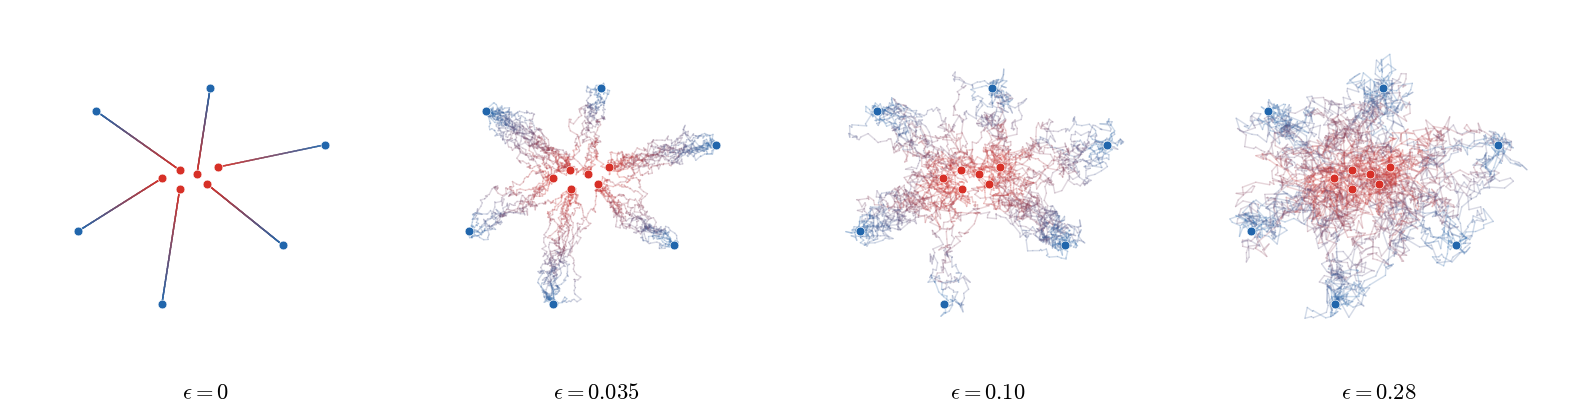

In [4]:
from IPython.display import Image as IPyImage, display
_thumb = Path("thumbnails/sinkhorn-path-space-bridges.png")
if not _thumb.exists():
    _thumb = ROOT / "notebooks-figures" / "thumbnails" / "sinkhorn-path-space-bridges.png"
display(IPyImage(filename=str(_thumb)))